<a href="https://colab.research.google.com/github/Jasemorin/BAC-StudentNotes/blob/main/ML/SUAIA_ML_workshop_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SUAIA Machine Learning Workshop

Welcome! In this hands-on workshop we'll build intuition for the **core pillars of modern ML** — from the ground up.

| # | Topic | What you'll build |
|---|-------|-------------------|
| 1 | **Linear Regression & Gradient Descent** | Train a model from scratch, visualise the loss landscape |
| 2 | **Logistic Regression & Classification** | Build a classifier, plot decision boundaries |
| 3 | **Neural Networks from Scratch** | Implement forward/back-prop, see a network learn XOR |
| 4 | **Reinforcement Learning** | Train a PPO agent to land on the moon 🚀 |

Each section includes the **math**, working **code**, and **visualisations** so you can see what's really going on under the hood.

In [ ]:
# Shared dependencies for the entire workshop
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from IPython.display import display, Markdown
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.grid': True,
    'font.size': 12
})

np.random.seed(42)
print("All imports ready ✓")

All imports ready ✓


---
# Material 1: Linear Regression & Gradient Descent

Linear regression is the *"Hello World"* of machine learning. It's the simplest model, but the optimisation technique behind it — **gradient descent** — is the same engine that powers trillion-parameter LLMs.

### The Model

We predict a target $y$ from a feature $x$ using:

$$\hat{y} = wx + b$$

where $w$ is the **weight** (slope) and $b$ is the **bias** (intercept).

### The Loss Function (Mean Squared Error)

We measure how wrong our predictions are with MSE:

$$L(w, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

### Gradient Descent Update Rule

To minimise the loss, we compute the partial derivatives and step in the opposite direction:

$$w \leftarrow w - \alpha \frac{\partial L}{\partial w}, \quad b \leftarrow b - \alpha \frac{\partial L}{\partial b}$$

where $\alpha$ is the **learning rate**.

The gradients work out to:

$$\frac{\partial L}{\partial w} = -\frac{2}{N}\sum_{i=1}^{N} x_i(y_i - \hat{y}_i), \quad \frac{\partial L}{\partial b} = -\frac{2}{N}\sum_{i=1}^{N}(y_i - \hat{y}_i)$$

In [ ]:
# --- Generate synthetic data ---
N = 100
X = 2 * np.random.rand(N)
y_true = 3.5 * X + 1.2 + np.random.randn(N) * 0.5  # true w=3.5, b=1.2

# --- Gradient descent from scratch ---
w, b = 0.0, 0.0
lr = 0.1
epochs = 100
history = {'epoch': [], 'loss': [], 'w': [], 'b': []}

for epoch in range(epochs):
    y_pred = w * X + b
    loss = np.mean((y_true - y_pred) ** 2)

    # Gradients
    dw = -2 / N * np.sum(X * (y_true - y_pred))
    db = -2 / N * np.sum(y_true - y_pred)

    # Update
    w -= lr * dw
    b -= lr * db

    history['epoch'].append(epoch)
    history['loss'].append(loss)
    history['w'].append(w)
    history['b'].append(b)

print(f"Learned: w = {w:.4f} (true: 3.5), b = {b:.4f} (true: 1.2)")
print(f"Final loss: {history['loss'][-1]:.4f}")

Learned: w = 3.5216 (true: 3.5), b = 1.1917 (true: 1.2)
Final loss: 0.1996


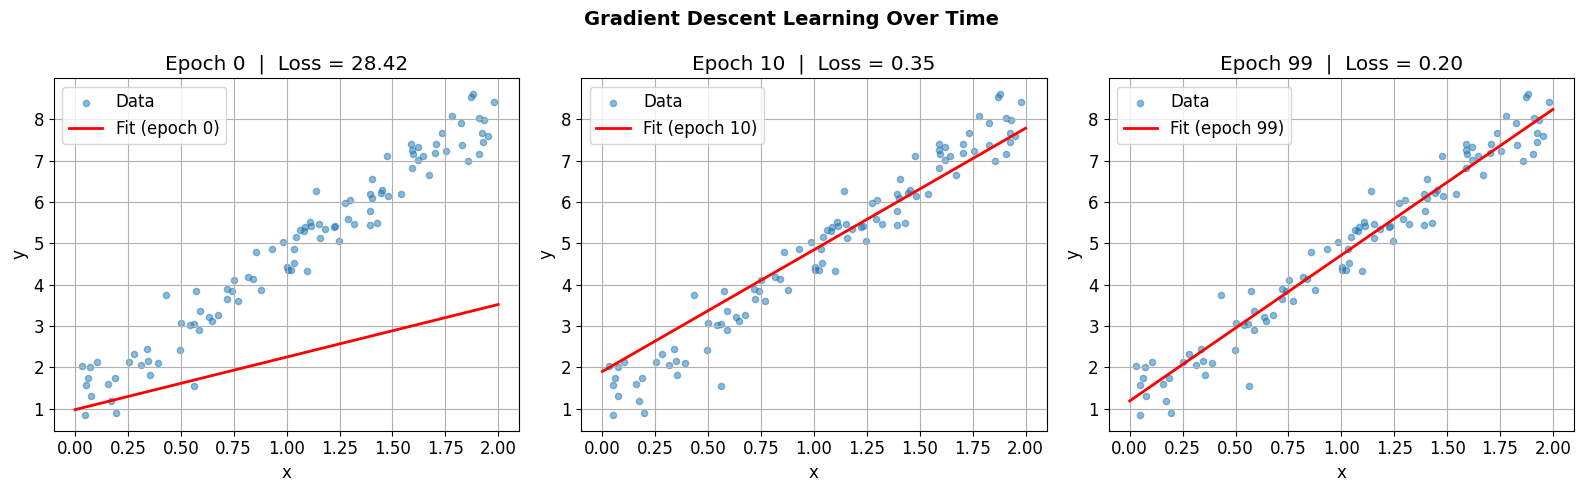

In [ ]:
# --- Visualisation 1: Data + fitted line at different epochs ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
snapshots = [0, 10, epochs - 1]

for ax, idx in zip(axes, snapshots):
    ax.scatter(X, y_true, alpha=0.5, s=20, label='Data')
    x_line = np.linspace(0, 2, 100)
    ax.plot(x_line, history['w'][idx] * x_line + history['b'][idx],
            'r-', linewidth=2, label=f"Fit (epoch {idx})")
    ax.set_title(f"Epoch {idx}  |  Loss = {history['loss'][idx]:.2f}")
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend()

plt.suptitle('Gradient Descent Learning Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

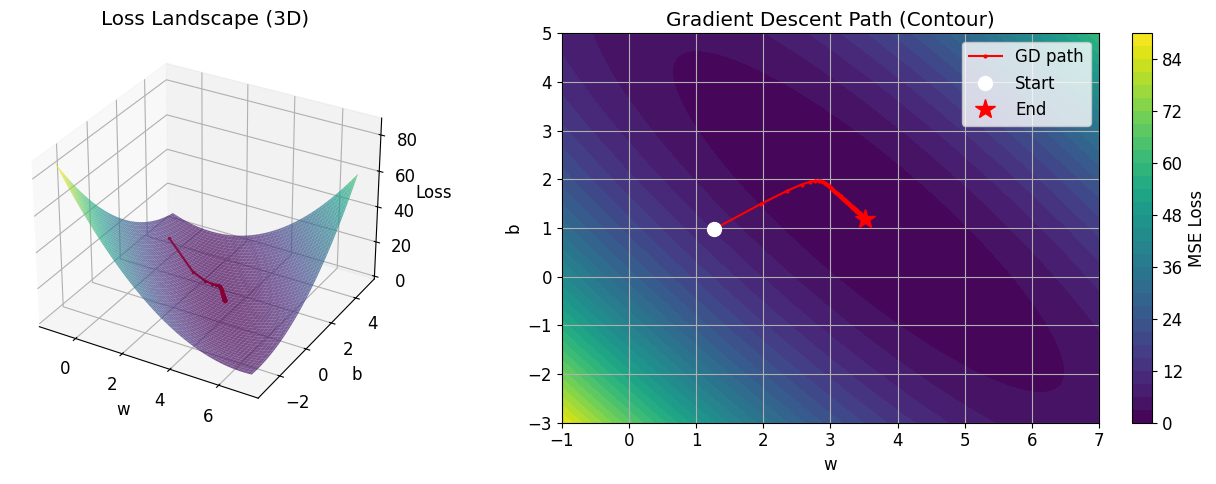

In [ ]:
# --- Visualisation 2: Loss landscape (3D surface + gradient path) ---
w_range = np.linspace(-1, 7, 100)
b_range = np.linspace(-3, 5, 100)
W, B = np.meshgrid(w_range, b_range)
Loss_surface = np.array([[np.mean((y_true - (wi * X + bi)) ** 2)
                          for wi in w_range] for bi in b_range])

fig = plt.figure(figsize=(14, 5))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(W, B, Loss_surface, cmap=cm.viridis, alpha=0.7)
ax1.plot(history['w'], history['b'], history['loss'], 'r.-', markersize=3, linewidth=1.5)
ax1.set_xlabel('w'); ax1.set_ylabel('b'); ax1.set_zlabel('Loss')
ax1.set_title('Loss Landscape (3D)')

# Contour plot with path
ax2 = fig.add_subplot(122)
cs = ax2.contourf(W, B, Loss_surface, levels=30, cmap=cm.viridis)
plt.colorbar(cs, ax=ax2, label='MSE Loss')
ax2.plot(history['w'], history['b'], 'r.-', markersize=4, linewidth=1.5, label='GD path')
ax2.plot(history['w'][0], history['b'][0], 'wo', markersize=10, label='Start')
ax2.plot(history['w'][-1], history['b'][-1], 'r*', markersize=15, label='End')
ax2.set_xlabel('w'); ax2.set_ylabel('b')
ax2.set_title('Gradient Descent Path (Contour)')
ax2.legend()

plt.tight_layout()
plt.show()

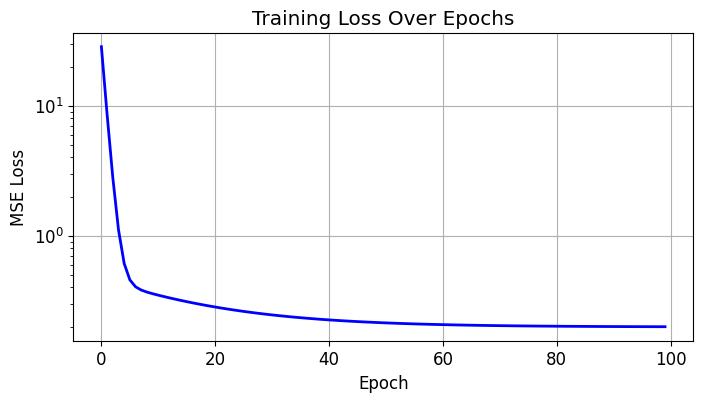

In [ ]:
# --- Visualisation 3: Loss curve ---
plt.figure(figsize=(8, 4))
plt.plot(history['epoch'], history['loss'], 'b-', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.yscale('log')
plt.show()

### 🧪 Exercise for attendees

1. Change the learning rate `lr` to `0.01` and `1.0`. What happens to the loss curve?
2. Increase the noise in the data (change `0.5` to `3.0`). Can the model still learn?
3. **Challenge:** Add a second feature (make it 2D regression). What changes in the math?

---
# Material 2: Logistic Regression & Classification

What if we want to predict a **category** instead of a number? We swap MSE for the **sigmoid** function and **binary cross-entropy** loss.

### The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

This squashes any real number into the range $(0, 1)$, which we interpret as a probability.

### The Model

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

### Binary Cross-Entropy Loss

$$L = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$

### Gradient

The gradient has an elegant form:

$$\frac{\partial L}{\partial \mathbf{w}} = \frac{1}{N} \mathbf{X}^T (\hat{\mathbf{y}} - \mathbf{y})$$

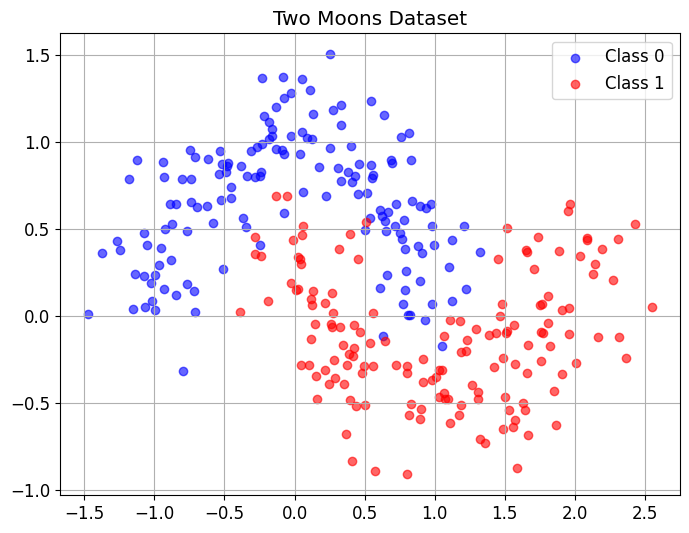

In [ ]:
# --- Generate 2D classification data ---
from sklearn.datasets import make_moons

X_cls, y_cls = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualise raw data
plt.figure(figsize=(8, 6))
plt.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1], c='red', label='Class 1', alpha=0.6)
# plt.xlabel('$x_1$'); p was lt.ylabel('$x_2$')
plt.title('Two Moons Dataset')
plt.legend()
plt.show()

In [ ]:
# --- Logistic Regression from scratch ---
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

# Add bias column
X_b = np.c_[np.ones(X_cls.shape[0]), X_cls]  # shape (300, 3)
theta = np.zeros(3)  # [bias, w1, w2]

lr = 0.5
epochs = 300
loss_history_cls = []

for epoch in range(epochs):
    z = X_b @ theta
    y_hat = sigmoid(z)

    # Binary cross-entropy
    eps = 1e-8
    loss = -np.mean(y_cls * np.log(y_hat + eps) + (1 - y_cls) * np.log(1 - y_hat + eps))
    loss_history_cls.append(loss)

    # Gradient & update
    grad = (1 / len(y_cls)) * X_b.T @ (y_hat - y_cls)
    theta -= lr * grad

accuracy = np.mean((sigmoid(X_b @ theta) >= 0.5) == y_cls)
print(f"Accuracy: {accuracy:.2%}")
print(f"Learned parameters: bias={theta[0]:.3f}, w1={theta[1]:.3f}, w2={theta[2]:.3f}")

Accuracy: 86.33%
Learned parameters: bias=0.403, w1=1.320, w2=-4.117


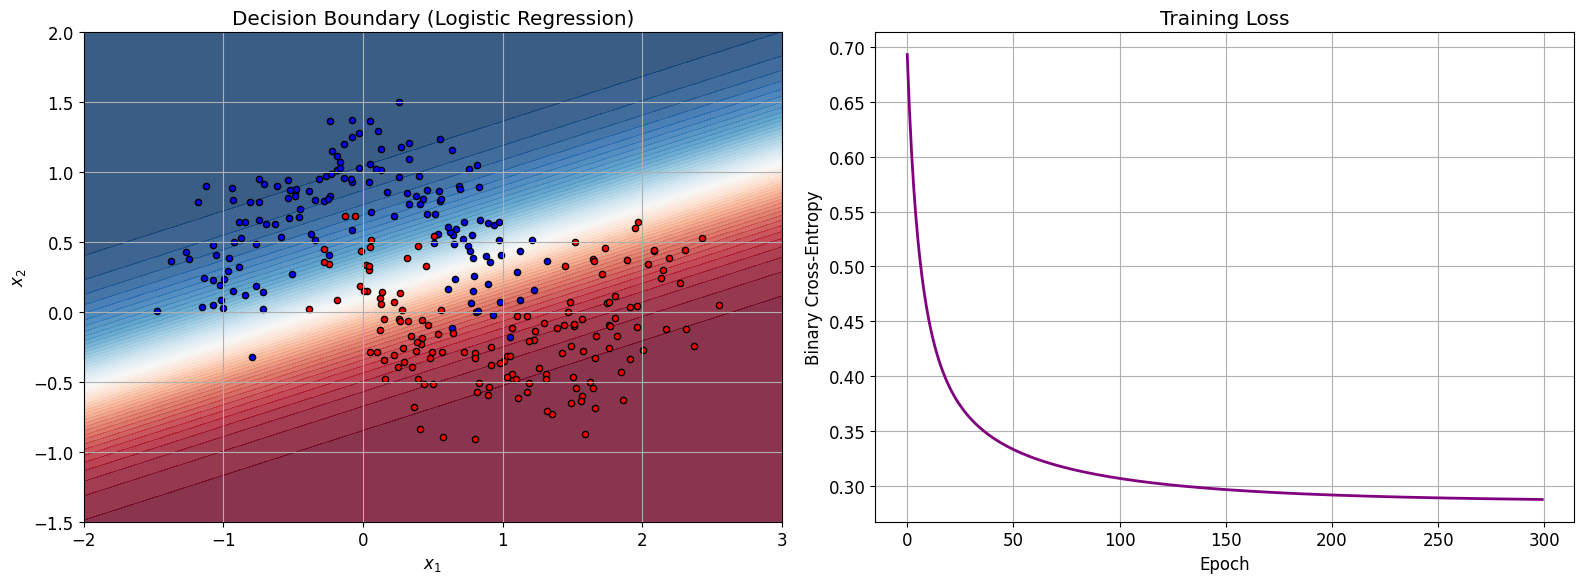


💡 Notice the decision boundary is a straight line — logistic regression is LINEAR.
   It can't perfectly separate the two moons. We need a neural network for that!


In [ ]:
# --- Visualisation: Decision boundary ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Decision boundary
ax = axes[0]
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = np.c_[np.ones(xx.ravel().shape[0]), xx.ravel(), yy.ravel()]
probs = sigmoid(grid @ theta).reshape(xx.shape)

ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.8)
ax.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1], c='blue', edgecolors='k', s=20)
ax.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1], c='red', edgecolors='k', s=20)
ax.set_title('Decision Boundary (Logistic Regression)')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Loss curve
ax2 = axes[1]
ax2.plot(loss_history_cls, 'purple', linewidth=2)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Binary Cross-Entropy')
ax2.set_title('Training Loss')

plt.tight_layout()
plt.show()

print("\n💡 Notice the decision boundary is a straight line — logistic regression is LINEAR.")
print("   It can't perfectly separate the two moons. We need a neural network for that!")

### 🧪 Exercise for attendees

1. What happens if you reduce `noise` to `0.05`? Does accuracy improve?
2. Try adding **polynomial features** (e.g., $x_1^2$, $x_2^2$, $x_1 x_2$). Can you bend the boundary?
3. What's the *maximum* accuracy a linear classifier can achieve on this moon-shaped data?

---
# Material 3: Neural Networks from Scratch

A neural network stacks **layers of logistic-regression-like units** with non-linear activations, giving it the power to learn complex decision boundaries.

### Forward Pass (one hidden layer)

$$\mathbf{h} = \text{ReLU}(\mathbf{X} \mathbf{W}_1 + \mathbf{b}_1)$$

$$\hat{\mathbf{y}} = \sigma(\mathbf{h} \mathbf{W}_2 + \mathbf{b}_2)$$

where $\text{ReLU}(z) = \max(0, z)$.

### Backpropagation (Chain Rule)

The key insight: we compute the gradient of the loss w.r.t. each parameter by **chaining** partial derivatives backwards through the network.

For the output layer:
$$\delta_2 = \hat{\mathbf{y}} - \mathbf{y}$$

$$\frac{\partial L}{\partial \mathbf{W}_2} = \mathbf{h}^T \delta_2$$

For the hidden layer:
$$\delta_1 = (\delta_2 \mathbf{W}_2^T) \odot \mathbf{1}_{\mathbf{h} > 0}$$

$$\frac{\partial L}{\partial \mathbf{W}_1} = \mathbf{X}^T \delta_1$$

The $\odot$ is element-wise multiplication and $\mathbf{1}_{\mathbf{h} > 0}$ is the ReLU derivative.

In [ ]:
# --- Neural Network from scratch ---
class SimpleNeuralNet:
    def __init__(self, input_dim, hidden_dim, output_dim):
        # Xavier initialisation
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(output_dim)

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        self.z1 = X @ self.W1 + self.b1
        self.h = self.relu(self.z1)
        self.z2 = self.h @ self.W2 + self.b2
        self.y_hat = self.sigmoid(self.z2)
        return self.y_hat

    def backward(self, X, y, lr):
        m = len(y)
        y = y.reshape(-1, 1)

        # Output layer gradients
        delta2 = self.y_hat - y               # (m, 1)
        dW2 = (1/m) * self.h.T @ delta2
        db2 = (1/m) * np.sum(delta2, axis=0)

        # Hidden layer gradients (backprop through ReLU)
        delta1 = (delta2 @ self.W2.T) * (self.z1 > 0)  # ReLU derivative
        dW1 = (1/m) * X.T @ delta1
        db1 = (1/m) * np.sum(delta1, axis=0)

        # Update
        self.W2 -= lr * dW2
        self.b2 -= lr * db2
        self.W1 -= lr * dW1
        self.b1 -= lr * db1

    def compute_loss(self, y):
        eps = 1e-8
        y = y.reshape(-1, 1)
        return -np.mean(y * np.log(self.y_hat + eps) + (1 - y) * np.log(1 - self.y_hat + eps))


# Train on the two-moons dataset
nn = SimpleNeuralNet(input_dim=2, hidden_dim=16, output_dim=1)
nn_losses = []

for epoch in range(1000):
    nn.forward(X_cls)
    loss = nn.compute_loss(y_cls)
    nn_losses.append(loss)
    nn.backward(X_cls, y_cls, lr=1.0)

preds = (nn.forward(X_cls) >= 0.5).flatten()
nn_accuracy = np.mean(preds == y_cls)
print(f"Neural Network Accuracy: {nn_accuracy:.2%}")
print(f"vs. Logistic Regression Accuracy: {accuracy:.2%}")

Neural Network Accuracy: 97.67%
vs. Logistic Regression Accuracy: 86.33%


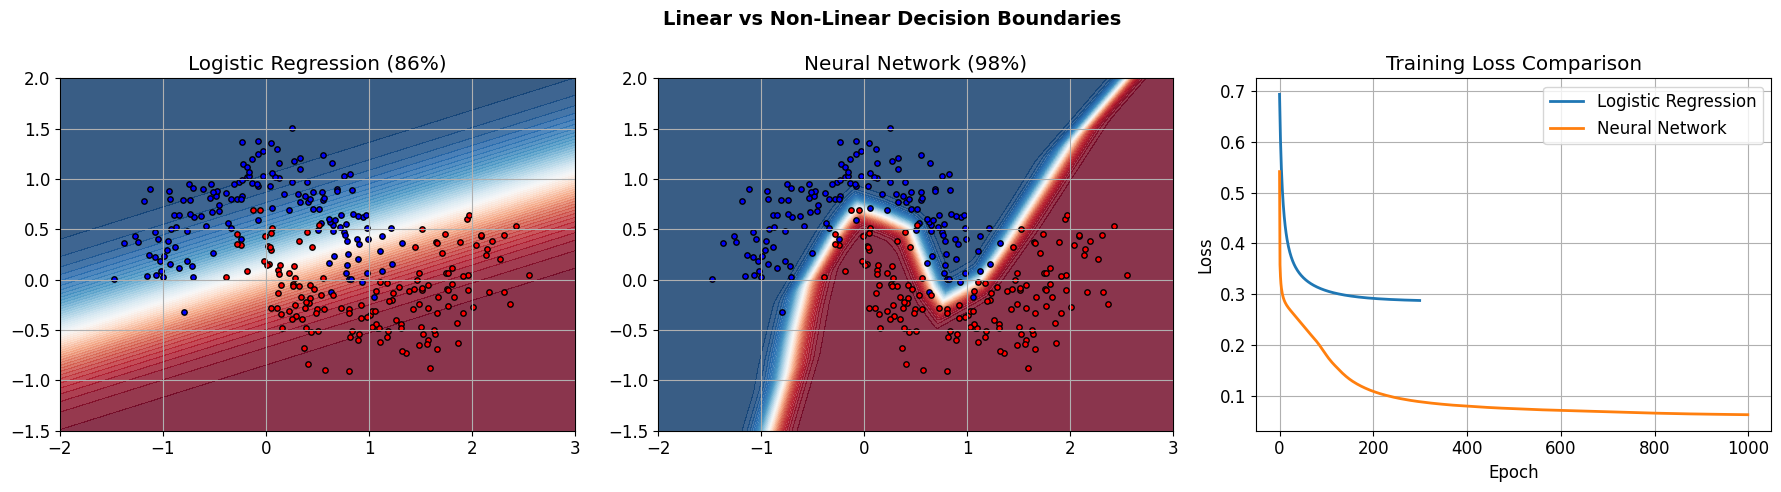

In [ ]:
# --- Visualisation: NN decision boundary vs Logistic Regression ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Logistic regression boundary
ax = axes[0]
probs_lr = sigmoid(grid @ theta).reshape(xx.shape)
ax.contourf(xx, yy, probs_lr, levels=50, cmap='RdBu_r', alpha=0.8)
ax.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1], c='blue', edgecolors='k', s=15)
ax.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1], c='red', edgecolors='k', s=15)
ax.set_title(f'Logistic Regression ({accuracy:.0%})')

# Neural network boundary
ax = axes[1]
grid_nn = np.c_[xx.ravel(), yy.ravel()]
probs_nn = nn.forward(grid_nn).reshape(xx.shape)
ax.contourf(xx, yy, probs_nn, levels=50, cmap='RdBu_r', alpha=0.8)
ax.scatter(X_cls[y_cls == 0, 0], X_cls[y_cls == 0, 1], c='blue', edgecolors='k', s=15)
ax.scatter(X_cls[y_cls == 1, 0], X_cls[y_cls == 1, 1], c='red', edgecolors='k', s=15)
ax.set_title(f'Neural Network ({nn_accuracy:.0%})')

# Loss comparison
ax = axes[2]
ax.plot(loss_history_cls, label='Logistic Regression', linewidth=2)
ax.plot(nn_losses, label='Neural Network', linewidth=2)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Training Loss Comparison')
ax.legend()

plt.suptitle('Linear vs Non-Linear Decision Boundaries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

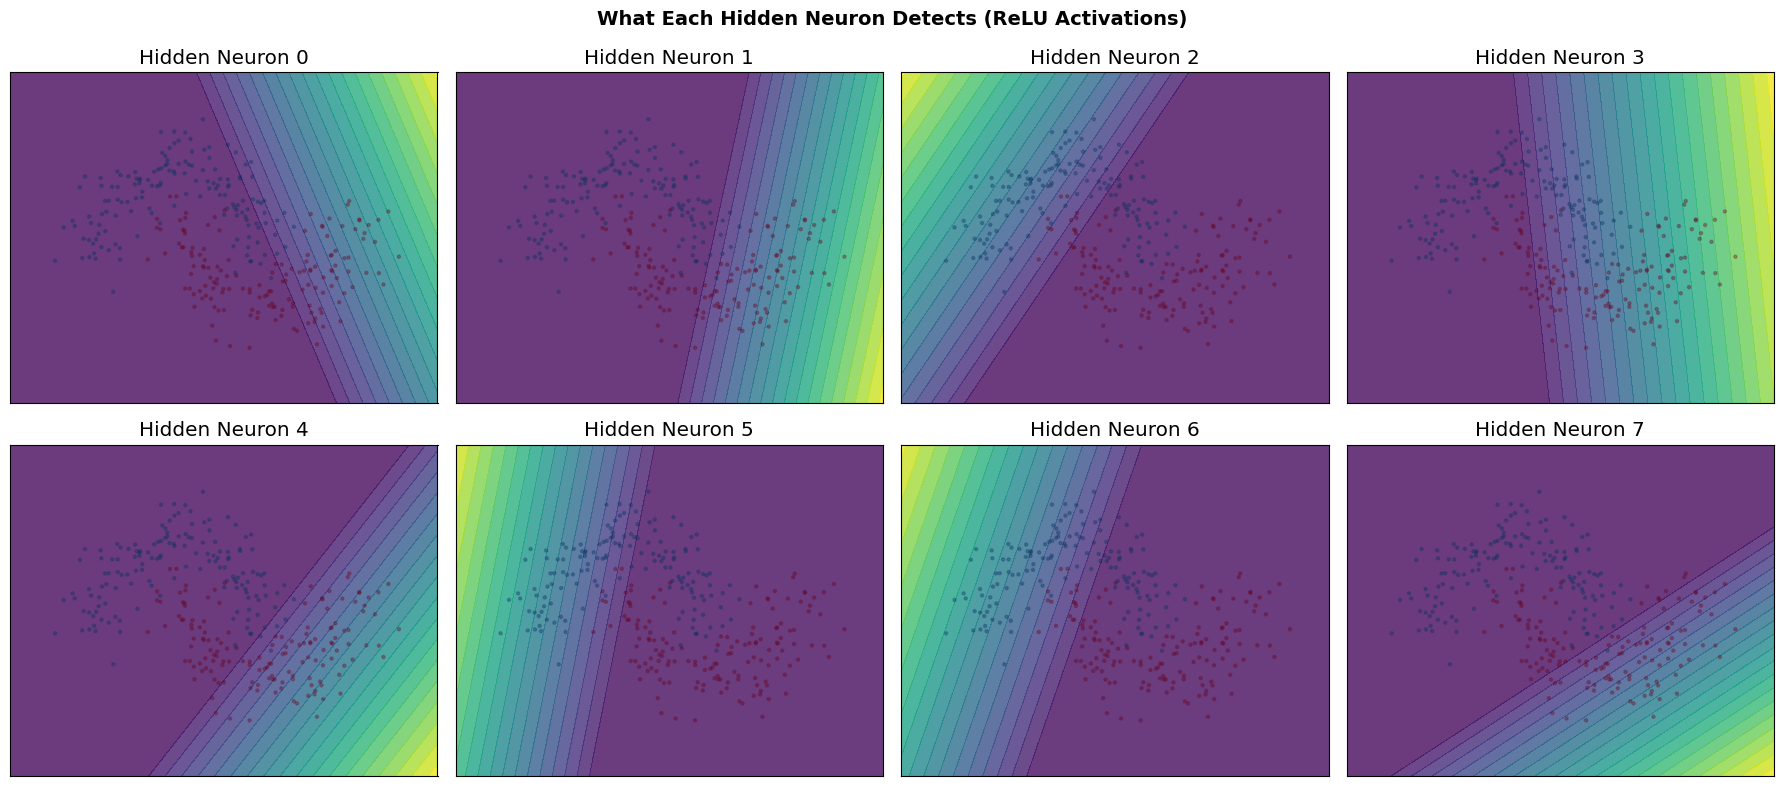

Each neuron learns a different linear 'slice' of the input space.
The output layer then COMBINES these slices to form the curved boundary!


In [ ]:
# --- Bonus: Visualise what individual hidden neurons learn ---
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i in range(min(8, nn.W1.shape[1])):
    # Each hidden neuron's activation across the input space
    activation = np.maximum(0, grid_nn @ nn.W1[:, i] + nn.b1[i]).reshape(xx.shape)
    axes[i].contourf(xx, yy, activation, levels=20, cmap='viridis', alpha=0.8)
    axes[i].scatter(X_cls[:, 0], X_cls[:, 1], c=y_cls, cmap='RdBu_r', s=5, alpha=0.3)
    axes[i].set_title(f'Hidden Neuron {i}')
    axes[i].set_xticks([]); axes[i].set_yticks([])

plt.suptitle('What Each Hidden Neuron Detects (ReLU Activations)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Each neuron learns a different linear 'slice' of the input space.")
print("The output layer then COMBINES these slices to form the curved boundary!")

### 🧪 Exercise for attendees

1. Change `hidden_dim` from 16 to 2. How does the decision boundary change? What about 128?
2. Replace ReLU with `tanh`. Does it converge faster or slower?
3. **Challenge:** Add a *second* hidden layer. What changes in the backprop code?

### 🧪 Exercise for attendees

1. Train a second model on the **clean** environment with the same timesteps. Compare scores.
2. Increase `flip_prob` to `0.3`. At what point does the agent fail completely?
3. **Discussion:** How does this relate to RLHF? (Hint: human labellers also give noisy, inconsistent feedback.)

---
# Wrap-Up

### What we covered today

| Topic | Key Takeaway |
|-------|--------------|
| Linear Regression | Gradient descent finds the minimum of a loss surface — the same algorithm behind all of deep learning |
| Logistic Regression | Sigmoid + cross-entropy = classification; but a linear boundary has limits |
| Neural Networks | Stacking non-linear layers lets us learn *any* decision boundary (universal approximation) |

### Where to go next
- **Deep Learning:** PyTorch tutorials → build CNNs, Transformers
- **LLMs:** Hugging Face Transformers library → fine-tune a small language model
- **Math:** 3Blue1Brown's *Neural Networks* series on YouTube